In [1]:
# using Pkg
# Pkg.activate("..")

using ITensors
using ITensorMPS
using PolyChaos
using LinearAlgebra
using Plots
using Observers
using Kronecker
using SparseArrays

using CorrelationProject

Id_check(Λi) = 4.440892098500626e-16

    #######################################################################
    Time evolution to calculate maps, propagators and steady state.
    #######################################################################
map_step = 1
After sweep 1: maxlinkdim=10 maxerr=7.22E-16 current_time=0.0 - 0.1im time=0.232
sim_t = 0.1
After sweep 1: maxlinkdim=10 maxerr=8.36E-16 current_time=0.0 + 0.1im time=0.041
After sweep 1: maxlinkdim=10 maxerr=7.25E-16 current_time=0.0 - 0.1im time=0.047
Time taken for map extraction
  0.011922 seconds (346.74 k allocations: 38.845 MiB)
After sweep 1: maxlinkdim=10 maxerr=3.88E-16 current_time=0.0 - 0.1im time=0.312
sim_t = 0.2
After sweep 1: maxlinkdim=10 maxerr=6.38E-16 current_time=0.0 + 0.1im time=0.098
After sweep 1: maxlinkdim=10 maxerr=7.94E-16 current_time=0.0 - 0.1im time=0.092
Time taken for map extraction
  0.017604 seconds (350.63 k allocations: 39.430 MiB, 30.68% gc time)
After sweep 1: maxlinkdim=10 maxerr

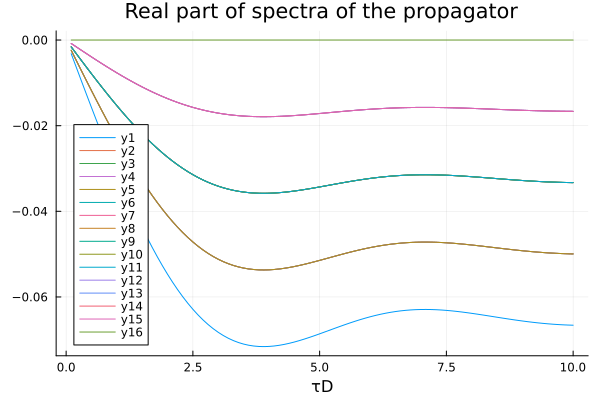

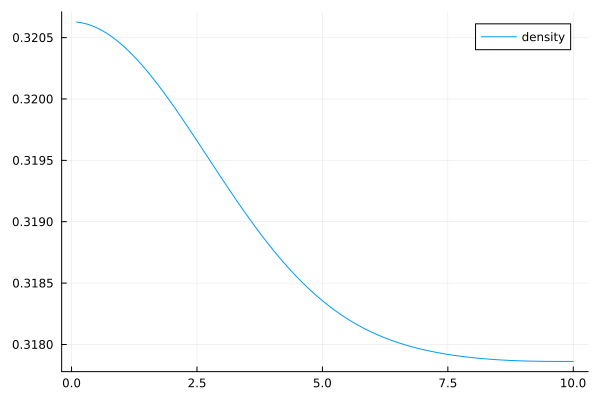

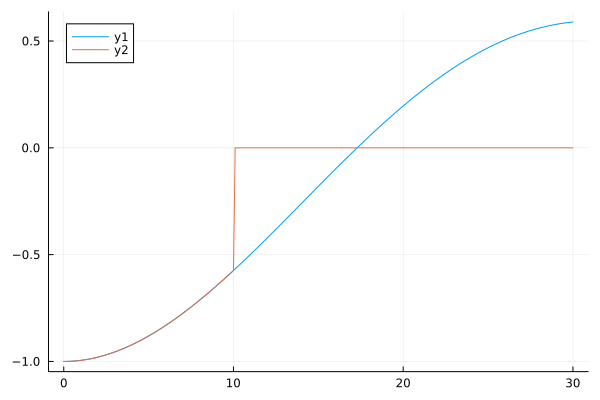

In [5]:
function multitime_correlators_using_NMQMpE_using_MPS(ψ0,H_MPO,τmL1,τmL2,τmL3,TDVP_params,end_time,site;kwargs...)

    """
    Step 1: Obtain converged objects
    -(a): Obtain L(τmL) and Λ(τmL) and L(τmL)'s zero eigenvalue, ρ∞
    -(b): Obtain ρf

    Step 2: Simulations using whole system and bath
    -(a): Evolve full system and bath density matrix, starting from the state
    ρ_tot(0) = ρf⊗ρ_B(0) up to time τmL. By construction,
    Tr_{B}(ρ_tot(τmL)) = ρ∞, where ρ_tot(τmL)= e^(-iHτmL)*ρ_tot(0)*e^(iHτmL).
    -(b): Create 2 new MPSs,  ϕ_L_greater=cdag|ρf(τmL)> and ϕ_L_greater=c|ρf(τmL)>.
    -(c): Evolve cdag|ρf(τmL)>,c|ρf(τmL)>,|ρf(τmL)> again by the full Hamiltonian, 
    up to time τmL.

    # Step 3: Only requires matrix multiplications in system Hilbert space
    # -(a): Trace out the bath to obtain \tilde{ρ}(τmL) = Tr_B(\tilde{ρ}_tot(τmL))
    # -(b): Obtain \tilde{ρ}(τ) = e^((τ-τmL)L)*\tilde{ρ}(τmL).
    
    
    Possible kwarg inputs:
    -τmL: the (guessed) memory time of the propagator. If not specified it will default to P.T.
    -use_spin_operators: boolean that decides whether to do the map calculation and rdms using 
    spin operators or fermionic operators (with appropriate corrections). Defaults to false.
    -take symmetry_subset: decides whether to only include the physically allowed matrix elements for the maps,
    defaults to true.
    -TDVP_nsite: defaults to 2.
    -enrich_bool: a boolean that decides whether to enrich every n*δt steps
    -cutoff: used for removal of noise for rdm_to_MPS, defaults to 1e-15
    """

    times1 = range(TDVP_params.δt,stop=τmL1,step = TDVP_params.δt)
    times2 = range(TDVP_params.δt,stop=τmL2,step = TDVP_params.δt) 
    TDVP_nsite = get(kwargs, :TDVP_nsite, 2)
    enrich_bool = get(kwargs,:enrich_bool,true)
    #take_symmetry_subset = get(kwargs,:take_symmetry_subset,false)
    ordering_choice = get(kwargs,:ordering_choice,"separated")
    use_spin_operators = get(kwargs,:use_spin_operators,false)
    plotting_bool = get(kwargs,:plotting_bool,false)
    memory_time_ind = get(kwargs,:memory_time_ind,false)
    @assert(end_time >= τmL2+τmL3)


    #Checking identity map
    Λi = calculateDynamicalMap(ψ0,layout,ordering_choice;use_spin_operators=false)
    @show(Id_check(Λi))

    #Step 1
    println("
    #######################################################################
    Time evolution to calculate maps, propagators and steady state.
    #######################################################################")
    

    #create observer for tdvp
    obs = Observer("times" => current_time,"corr" => measure_correlation_matrix)

    TDVP_params.total_simulation_time= τmL1
    ψ,map_calc_obs,L_vec,Λ_vec,map_times =  propagate_MPS(ψ0,H_MPO,obs,TDVP_params,layout;compute_maps_bool=true, kwargs...)

    spectra_vec,SS_vec = calculate_spectra_and_steady_state(L_vec)
    if plotting_bool
        display(Plots.plot(map_times,real.(spectra_vec),title="Real part of spectra of the propagator",xlabel="τD"))
    end

    #gives an option to choose the specific point where the fast state is calculated
    if memory_time_ind == false
        Lτm,Λτm,steady_state = L_vec[end],Λ_vec[end],SS_vec[end]
    else
        Lτm,Λτm,steady_state = Lτm,[Int(memory_time_ind)],Λ_vec[Int(memory_time_ind)],SS_vec[Int(memory_time_ind)]
    end


    @show(map_check(ψ,ψ0,Λτm,layout))

    # if take_symmetry_subset
    #     ρf= unvectorise_ρ(expand_Λ(pinv(Λτm),P.Ns)*NESS,true)
    # else
    ρf= unvectorise_ρ(pinv(Λτm)*steady_state,true)
    #if ρf is unphysical, this finds one that is
    if sum(real.(eigen(ρf).values) .<0) > 0
        ρf_bool = false
        for i =reverse(1:length(L_vec))
            spec = eigen(L_vec[i]).values
            vecs = eigen(L_vec[i]).vectors
            steady_state_i = vecs[:,argmin(abs.(spec))]
            ρf_test = unvectorise_ρ(pinv(Λ_vec[i])*steady_state_i,true)
            if sum(real.(eigen(ρf).values) .<0) == 0
                ρf = ρf_test   
                ρf_bool = true
            end
        end
        if ρf_bool == false
            ρf = unvectorise_ρ(steady_state,true)
        end
    end  


    if ordering_choice == "interleaved"
        println("
        For the purified MPS to give the fast state after 
        tracing out, the ancillas must be contiguous. So, if
        an interleaved system-ancilla setup was used to calculate the 
        map, then this must be switched at this point. This code assumes a separated ordering
        is used at all times to avoid this complication, so using an interleaved ordering
        is not currently implemented")
    end

    #creating an MPS that defines the purified ρf
    ρf_MPS = rdm_to_MPS(ρf,siteinds(ψ),layout)

    #testing it gives the fast state after tracing out
    ρf_test = vectorise_ρ(ρf_MPS,layout)

    
    @show(norm(ρf_test-vectorise_mat(ρf)))

    println("
    #######################################################################
    Time evolution towards stationarity, starting with ρf
    #######################################################################")
    #Step 2

    #create observer for tdvp
    obs = Observer("times" => current_time,"corr" => measure_correlation_matrix)

    TDVP_params.total_simulation_time = τmL2
    ρf_MPS_evolved,SS_prep_obs=  propagate_MPS(ρf_MPS,H_MPO,obs,TDVP_params,layout;compute_maps_bool = false,kwargs...)
    
    #save_object("ρf_MPS_evolved.jld2",ρf_MPS_evolved)

    #some plotting showing the thermalisation
    corrs = SS_prep_obs.corr
    den_vec = [corr[site,site] for corr in corrs]
    if plotting_bool
        display(Plots.plot(times2,real.(den_vec),label="density"))
    end

        
    ρf_evolved_mat = vectorise_ρ(ρf_MPS_evolved,layout)
    #Test to show if ρf gives the steady state after the evolution
    # if take_symmetry_subset
    #     @show(norm(ρf_evolved_mat-expand_Λ(Λτm,P.Ns)*ρf_test))
    # else
    @show(norm(ρf_evolved_mat-Λτm*ρf_test))
    @show(norm(steady_state-ρf_evolved_mat))


    println("
    #######################################################################
    Once stationary the state is perturbed with the appropriate 
    creation/annihilation operators for the greens function calulations.
    #######################################################################")
    ##Creating ϕ_L_greater, ϕ_R_greater, ϕ_L_lesser and ϕ_R_lesser
    ##ϕ_R_greater and ϕ_L_lesser are calculated from ϕ=U(t)*ρf_evolved
    ϕ = deepcopy(ρf_MPS_evolved)

    s = siteinds(ϕ)
    ϕ_L_greater = apply(create_fermi_cre_op(layout.system[site],[layout.system;layout.ancilla],op(s,"Cdag",layout.system[site]),s),ϕ)
    ϕ_R_lesser = apply(create_fermi_ann_op(layout.system[site],[layout.system;layout.ancilla],op(s,"C",layout.system[site]),s),ϕ)

    Nsteps = Int(end_time/TDVP_params.δt)
    Grn_t = zeros(ComplexF64, Nsteps+1)
    Grn_lesser,Grn_greater = similar(Grn_t),similar(Grn_t)
    Grn_t[1] = -1.0*im ##t=0 value
    Grn_t_test = deepcopy(Grn_t)

    println("
    #######################################################################
    The three MPSs required for the greens function are propagated for a time
    τmL, after which their evolution can be described by propagation
    with the fixed propagator.
    #######################################################################")
    # Configure updater parameters
    updater_kwargs = Dict(:ishermitian => true, :issymmetric => true, :eager => true)
    sim_t = 0
    no_of_tdvp_steps = Int(τmL3/TDVP_params.δt)


    cdag_mat,c_mat = matrix_operators(length(layout.system))
    ρ_tilde_lesser_vec = Vector{Any}(undef,Nsteps+1)
    ρ_tilde_greater_vec = Vector{Any}(undef,Nsteps+1)
    ρ_tilde_lesser_vec[1] = vectorise_ρ(ϕ,ϕ_R_lesser,layout;rdm_block_sparse_bool = false,kwargs...)
    ρ_tilde_greater_vec[1] = vectorise_ρ(ϕ_L_greater,ϕ,layout;rdm_block_sparse_bool = false,kwargs...)

    
    for i =1:(no_of_tdvp_steps)
        ϕ_L_greater= tdvp(H_MPO,-im * TDVP_params.δt,ϕ_L_greater; time_step = -im * TDVP_params.δt, cutoff = TDVP_params.tdvp_cutoff,
        mindim=TDVP_params.minbonddim,maxdim=TDVP_params.maxbonddim,outputlevel=1, normalize=false,updater_kwargs, reverse_step = true)
    
        ϕ_R_lesser = tdvp(H_MPO,-im * TDVP_params.δt,ϕ_R_lesser; time_step = -im * TDVP_params.δt, cutoff = TDVP_params.tdvp_cutoff,
        mindim=TDVP_params.minbonddim,maxdim=TDVP_params.maxbonddim,outputlevel=1, normalize=false,updater_kwargs,reverse_step = true)

        ϕ = tdvp(H_MPO,-im * TDVP_params.δt,ϕ; time_step = -im * TDVP_params.δt, cutoff = TDVP_params.tdvp_cutoff,
        mindim=TDVP_params.minbonddim,maxdim=TDVP_params.maxbonddim,outputlevel=1, normalize=true,updater_kwargs,reverse_step = true)
        
        ##Calculating ϕ_R_greater and ϕ_L_lesser
        ϕ_R_greater = apply(create_fermi_cre_op(layout.system[site],[layout.system;layout.ancilla],op(s,"Cdag",layout.system[site]),s),ϕ)
        ϕ_L_lesser = apply(create_fermi_cre_op(layout.system[site],[layout.system;layout.ancilla],op(s,"C",layout.system[site]),s),ϕ)

        Grn_lesser[i+1] = im*inner(ϕ_R_lesser,ϕ_L_lesser)
        Grn_greater[i+1] = -im*inner(ϕ_R_greater,ϕ_L_greater)
        Grn_t[i+1] = Grn_greater[i+1]-Grn_lesser[i+1]

        ρ_tilde_lesser = vectorise_ρ(ϕ,ϕ_R_lesser,layout;rdm_block_sparse_bool = false,kwargs...) 
        ρ_tilde_greater= vectorise_ρ(ϕ_L_greater,ϕ,layout;rdm_block_sparse_bool = false,kwargs...)
        G_greater = -im*tr(c_mat[site]*unvectorise_ρ(ρ_tilde_greater,false))
        G_lesser = im*tr(c_mat[site]*unvectorise_ρ(ρ_tilde_lesser,false))
        Grn_t_test[i+1] = G_greater-G_lesser

        ρ_tilde_lesser_vec[i+1] = ρ_tilde_lesser
        ρ_tilde_greater_vec[i+1] = ρ_tilde_greater
        sim_t += TDVP_params.δt
        @show(sim_t)
    end

    ρ_tilde_lesser = ρ_tilde_lesser_vec[no_of_tdvp_steps+1]
    ρ_tilde_greater = ρ_tilde_greater_vec[no_of_tdvp_steps+1]

    println("
    #######################################################################
    After τmL, ρ_tilde_lesser and ρ_tilde_greater are calculated and are 
    propagated using the converged propagator.
    #######################################################################")
    
    #Applies parity correction
    Sz = spin_operators(length(layout.system))[1]
    parity_op = Matrix(Sz[1])
    for i=2:length(layout.system)
        parity_op *= Matrix(Sz[i])
    end
    parity_op_vec = lmult(parity_op)
    Lbar_τm = parity_op_vec*Lτm*parity_op_vec

    remaining_steps = Int((end_time-τmL3)/TDVP_params.δt)
    for i = 1:remaining_steps
        ρ_tilde_lesser = exp(Lbar_τm*TDVP_params.δt)*ρ_tilde_lesser
        ρ_tilde_greater = exp(Lbar_τm*TDVP_params.δt)*ρ_tilde_greater

        Grn_greater[no_of_tdvp_steps+i+1] = -im*tr(c_mat[site]*unvectorise_ρ(ρ_tilde_greater,false))
        Grn_lesser[no_of_tdvp_steps+i+1] = im*tr(c_mat[site]*unvectorise_ρ(ρ_tilde_lesser,false))
        Grn_t[no_of_tdvp_steps+i+1] = Grn_greater[no_of_tdvp_steps+i+1]-Grn_lesser[no_of_tdvp_steps+i+1]
    end
    
    total_times = range(0,stop=end_time,step=TDVP_params.δt)
    output_dict = Dict()
    output_dict["Grn_t"] = Grn_t
    output_dict["Grn_lesser"] = Grn_lesser
    output_dict["Grn_greater"] = Grn_greater
    output_dict["total_times"] = total_times
    output_dict["L_vec"] = L_vec
    output_dict["Λ_vec"] = Λ_vec
    output_dict["SS_prep_obs"] = SS_prep_obs
    output_dict["map_calc_obs"] = map_calc_obs
    output_dict["ρf_MPS"] = ρf_MPS
    output_dict["ρf_MPS_evolved"] = ρf_MPS_evolved
    output_dict["ρ_tilde_lesser"] = ρ_tilde_lesser
    output_dict["ρ_tilde_greater"] = ρ_tilde_greater
    output_dict["τmLs"] = [τmL1,τmL2,τmL3]
    output_dict["ϕ_R_lesser"] = ϕ_R_lesser
    output_dict["ϕ_L_greater"] = ϕ_L_greater
    output_dict["ϕ"] = ϕ
    output_dict["Grn_t_test"] = Grn_t_test
    output_dict["ρ_tilde_greater_vec"] = ρ_tilde_greater_vec
    output_dict["ρ_tilde_lesser_vec"] = ρ_tilde_lesser_vec
    return output_dict
end


"""
Define parameters
"""

left_bath = BathParameters(Γ = 0.05,β = 10.0,μ = 0.1,D = 1.0,N =0)

right_bath = BathParameters(Γ = 0.05,β = 10.0,μ = -0.1,D = 1.0,N = 10)

system = SystemParameters(ϵ = [0.0,0.0],t = [0.1],U = [0.0],occupations=["Emp","Emp"])

layout =ChainLayout(left_bath.N,right_bath.N,length(system.ϵ))

TDVP_params = TDVP_parameters(tdvp_cutoff = 1e-10,minbonddim = 10,maxbonddim = 40,δt = 0.1,total_simulation_time = 10)

times = range(TDVP_params.δt,stop = TDVP_params.total_simulation_time,step = TDVP_params.δt)

"""
Create initial MPS
"""
sites = siteinds("Fermion",2*left_bath.N+2*right_bath.N + 2*length(system.ϵ);conserve_qns=true)
initial_occupations = thermofield_state(left_bath,right_bath,system)
ψ0 = MPS(ComplexF64,sites,initial_occupations)
ψ0 = create_Choi_state(ψ0,layout);

Λi = calculateDynamicalMap(ψ0,layout,"separated")

"""
Create single particle Hamiltonian and many-body MPO
"""

H_MPO,Hsingle =build_hamiltonian(sites,left_bath,right_bath,system);


"""
Define parameters for correlation function calculation
"""

τmL1 = 10
τmL2 = 10
τmL3 = 10

TDVP_params = TDVP_params
end_time = 30
site = 1

output_dict = multitime_correlators_using_NMQMpE_using_MPS(
    ψ0,
    H_MPO,
    τmL1,
    τmL2,
    τmL3,
    TDVP_params,
    end_time,
    site;
    map_step = 1,
    take_symmetry_subset=false,
    plotting_bool=true,
    memory_time_ind = false);


Plots.plot(output_dict["total_times"],imag.(output_dict["Grn_t"]))
Plots.plot!(output_dict["total_times"],imag.(output_dict["Grn_t_test"]))
